# Preference for Experimentation — v2
Julian Hsu

Implements the dynamic loss function from `Preference_for_Experimentation_Theory.md`.

**Key changes from v1:**
- No Thompson Sampling. Loss is fully deterministic given current data; stochasticity comes only from realized outcomes.
- Precision term uses live estimation uncertainty `sigma^2/n_T + sigma^2/n_C`, which shrinks as data accumulates. Exploration phases out endogenously.
- Variance term uses posterior-expected between-arm variance `(T_bar - C_bar)^2 + sigma^2/n_T + sigma^2/n_C`.

## Loss Function

$$L_t(p) = -[p\bar{T} + (1-p)\bar{C}] + \lambda\bigl[\sigma^2 + p(1-p)\bigl((\bar{T}-\bar{C})^2 + \tfrac{\sigma^2}{n_T} + \tfrac{\sigma^2}{n_C}\bigr)\bigr] - \eta\cdot p(1-p)\cdot\bigl(\tfrac{\sigma^2}{n_T} + \tfrac{\sigma^2}{n_C}\bigr)$$

Factoring out $p(1-p)$, the estimation noise terms appear with net coefficient $(\lambda - \eta)$:

$$L_t(p) = -\text{reward} + \lambda\sigma^2 + p(1-p)\!\left[\lambda(\bar{T}-\bar{C})^2 + (\lambda - \eta)\cdot\underbrace{\left(\frac{\sigma^2}{n_T} + \frac{\sigma^2}{n_C}\right)}_{\to\,0\text{ as data grows}}\right]$$

**Curvature:** $d^2L/dp^2 = -2\lambda(\bar{T}-\bar{C})^2 + 2(\eta-\lambda)(\sigma^2/n_T + \sigma^2/n_C)$

| Regime | Condition | Optimal $p$ |
|---|---|---|
| Never experiments | $\lambda \geq \eta$ | Corner (p = 0.05 or 0.95) always |
| Experiments then commits | $\eta > \lambda$, large est. noise | Interior early, corner late |

As $n_T, n_C \to \infty$ the estimation noise vanishes and all agents converge to corners.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Experiment parameters — agent never observes these directly
true_effect = -3.0      # treatment is harmful; true optimum is all-control
noise       = 9.0
var_known   = noise**2  # 81 — agent knows sigma^2 from experiment design
n_per_round = 50
T           = 20
p_grid      = np.linspace(0.05, 0.95, 19)

In [2]:
def compute_loss(p, T_bar, C_bar, n_t, n_c, lam, eta):
    """
    L(p) = -reward + lam*variance - eta*precision

    variance  = sigma^2 + p(1-p)*[(T_bar-C_bar)^2 + sigma^2/n_t + sigma^2/n_c]
    precision = p(1-p) * (sigma^2/n_t + sigma^2/n_c)  <- shrinks as data grows
    """
    est_noise = var_known / n_t + var_known / n_c
    reward    = p * T_bar + (1 - p) * C_bar
    variance  = var_known + p * (1 - p) * ((T_bar - C_bar)**2 + est_noise)
    precision = p * (1 - p) * est_noise
    return -reward + lam * variance - eta * precision


def choose_p(T_bar, C_bar, n_t, n_c, lam, eta):
    """Grid-search over p_grid. Always called with n_t >= 1, n_c >= 1."""
    losses = np.array([compute_loss(p, T_bar, C_bar, n_t, n_c, lam, eta)
                       for p in p_grid])
    return p_grid[np.argmin(losses)]


def simulate(lam, eta, seed=None):
    """Run one T-round experiment. Returns allocation array of shape (T,).

    Initialises with one random draw from each arm so the loss function has
    genuine (noisy) starting estimates rather than an arbitrary prior mean.
    """
    if seed is not None:
        np.random.seed(seed)

    # One real observation per arm before the experiment begins
    treat_obs = list(true_effect + np.random.normal(0, noise, 1))
    ctrl_obs  = list(np.random.normal(0, noise, 1))

    allocs = []
    for _ in range(T):
        n_t   = len(treat_obs)
        n_c   = len(ctrl_obs)
        T_bar = np.mean(treat_obs)
        C_bar = np.mean(ctrl_obs)
        p = choose_p(T_bar, C_bar, n_t, n_c, lam, eta)
        n_t_new = min(max(int(round(n_per_round * p)), 1), n_per_round - 1)
        n_c_new = n_per_round - n_t_new
        allocs.append(n_t_new / n_per_round)
        treat_obs.extend(true_effect + np.random.normal(0, noise, n_t_new))
        ctrl_obs.extend(np.random.normal(0, noise, n_c_new))
    return np.array(allocs)

In [3]:
lambda_vals = np.array([0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0])
eta_vals    = np.array([0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0])
n_runs      = 30
seeds       = list(range(n_runs))

print(f"Running {len(lambda_vals) * len(eta_vals) * n_runs:,} simulations...", flush=True)
sweep = {}
for lam, eta in product(lambda_vals, eta_vals):
    sweep[(lam, eta)] = np.stack([simulate(lam, eta, seed=s) for s in seeds])
print("Done.")

Running 1,920 simulations...


Done.


In [4]:
nL, nE = len(lambda_vals), len(eta_vals)
# rows = eta (y-axis, origin='lower'), cols = lambda (x-axis)
mean_early = np.zeros((nE, nL))   # rounds 1-5
mean_all   = np.zeros((nE, nL))   # all rounds
mean_late  = np.zeros((nE, nL))   # rounds 16-20

for i, eta in enumerate(eta_vals):
    for j, lam in enumerate(lambda_vals):
        runs = sweep[(lam, eta)]            # (n_runs, T)
        mean_early[i, j] = runs[:, :5].mean()
        mean_all[i, j]   = runs.mean()
        mean_late[i, j]  = runs[:, -5:].mean()

print("Early (rounds 1-5):")
print(np.round(mean_early, 2))
print("\nLate (rounds 16-20):")
print(np.round(mean_late, 2))

Early (rounds 1-5):
[[0.23 0.23 0.23 0.23 0.23 0.23 0.23 0.23]
 [0.19 0.23 0.23 0.23 0.23 0.23 0.23 0.23]
 [0.2  0.19 0.23 0.23 0.23 0.23 0.23 0.23]
 [0.18 0.19 0.19 0.23 0.23 0.23 0.23 0.23]
 [0.22 0.19 0.18 0.2  0.23 0.23 0.23 0.23]
 [0.3  0.28 0.23 0.21 0.19 0.23 0.23 0.23]
 [0.39 0.37 0.34 0.29 0.25 0.2  0.23 0.23]
 [0.44 0.44 0.43 0.4  0.34 0.26 0.22 0.23]]

Late (rounds 16-20):
[[0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
 [0.09 0.06 0.05 0.05 0.04 0.04 0.04 0.04]]


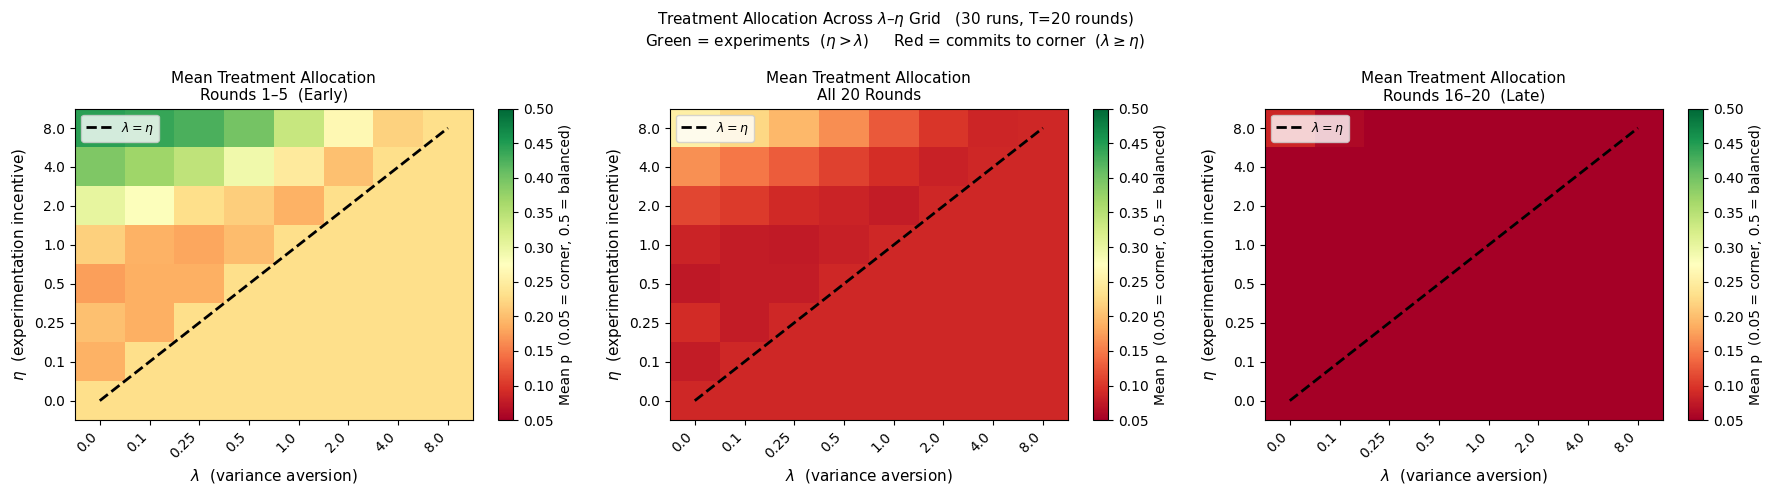

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Rounds 1–5  (Early)', 'All 20 Rounds', 'Rounds 16–20  (Late)']
data   = [mean_early, mean_all, mean_late]

for ax, dat, title in zip(axes, data, titles):
    im = ax.imshow(dat, origin='lower', aspect='auto',
                   vmin=0.05, vmax=0.5, cmap='RdYlGn')
    ax.set_xticks(range(nL))
    ax.set_xticklabels([str(v) for v in lambda_vals], rotation=45, ha='right')
    ax.set_yticks(range(nE))
    ax.set_yticklabels([str(v) for v in eta_vals])
    ax.set_xlabel(r'$\lambda$  (variance aversion)', fontsize=11)
    ax.set_ylabel(r'$\eta$  (experimentation incentive)', fontsize=11)
    ax.set_title(f'Mean Treatment Allocation\n{title}', fontsize=11)
    # lambda = eta diagonal (both arrays are identical)
    ax.plot(range(min(nL, nE)), range(min(nL, nE)),
            'k--', linewidth=2, label=r'$\lambda = \eta$')
    ax.legend(fontsize=9)
    plt.colorbar(im, ax=ax, label='Mean p  (0.05 = corner, 0.5 = balanced)')

plt.suptitle(
    r'Treatment Allocation Across $\lambda$–$\eta$ Grid   (30 runs, T=20 rounds)'
    '\nGreen = experiments  ($\\eta > \\lambda$)     Red = commits to corner  ($\\lambda \\geq \\eta$)',
    fontsize=11
)
plt.tight_layout()
plt.show()

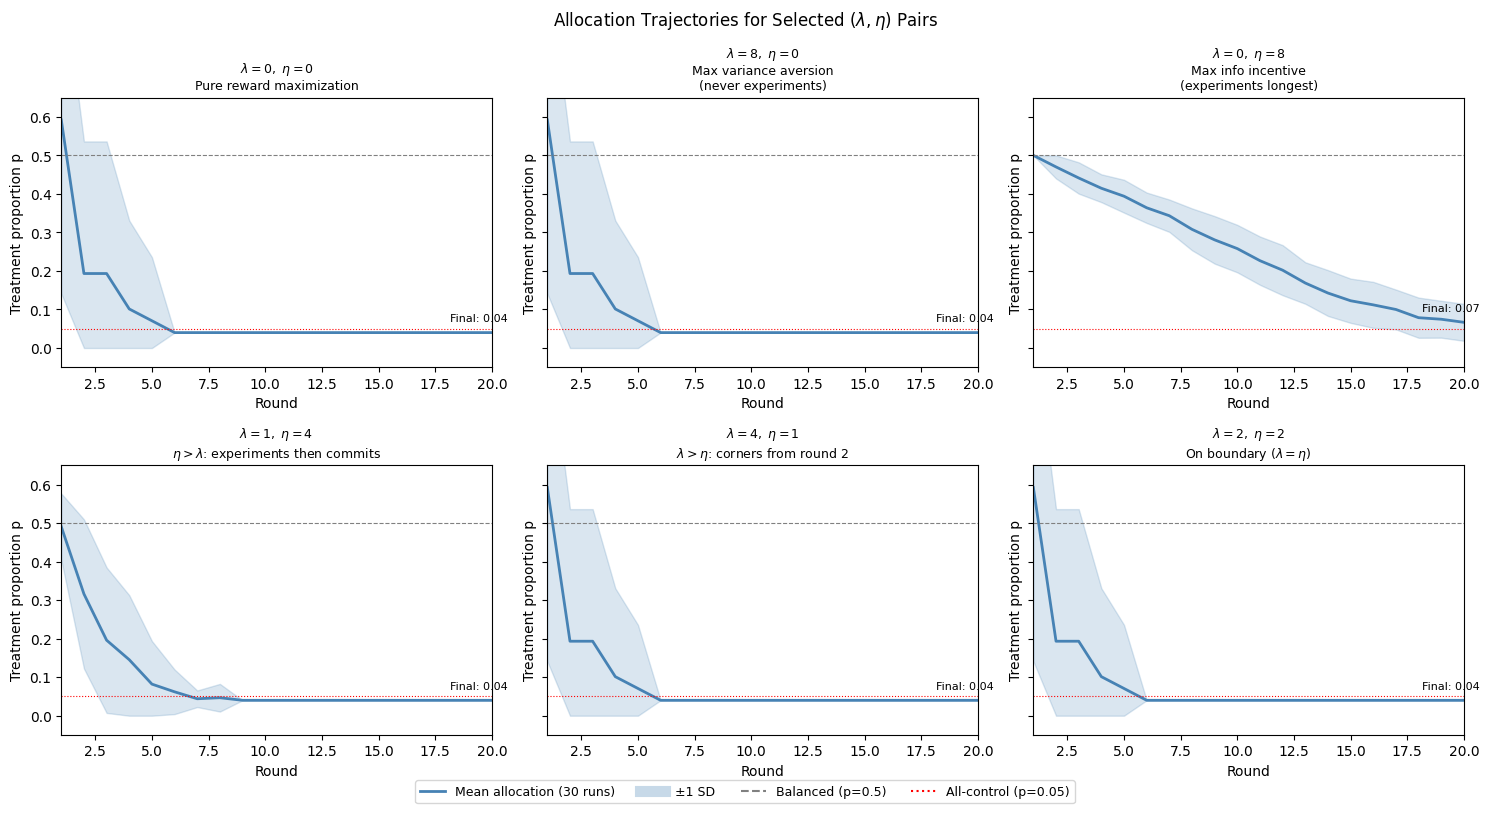

In [6]:
cases = [
    (0.0, 0.0, '$\\lambda=0,\ \\eta=0$\nPure reward maximization'),
    (8.0, 0.0, '$\\lambda=8,\ \\eta=0$\nMax variance aversion\n(never experiments)'),
    (0.0, 8.0, '$\\lambda=0,\ \\eta=8$\nMax info incentive\n(experiments longest)'),
    (1.0, 4.0, '$\\lambda=1,\ \\eta=4$\n$\\eta > \\lambda$: experiments then commits'),
    (4.0, 1.0, '$\\lambda=4,\ \\eta=1$\n$\\lambda > \\eta$: corners from round 2'),
    (2.0, 2.0, '$\\lambda=2,\ \\eta=2$\nOn boundary ($\\lambda = \\eta$)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
rounds = np.arange(1, T + 1)

for ax, (lam, eta, label) in zip(axes.flat, cases):
    runs = sweep[(lam, eta)]
    m = runs.mean(axis=0)
    s = runs.std(axis=0)
    ax.plot(rounds, m, linewidth=2, color='steelblue')
    ax.fill_between(rounds, np.clip(m - s, 0, 1), np.clip(m + s, 0, 1),
                    alpha=0.2, color='steelblue')
    ax.axhline(0.5,  linestyle='--', color='gray', linewidth=0.8)
    ax.axhline(0.05, linestyle=':',  color='red',  linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Round')
    ax.set_ylabel('Treatment proportion p')
    ax.set_ylim(-0.05, 0.65)
    ax.set_xlim(1, T)
    ax.annotate(f'Final: {m[-1]:.2f}', xy=(T, m[-1]),
                xytext=(-30, 8), textcoords='offset points', fontsize=8)

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color='steelblue', lw=2,    label='Mean allocation (30 runs)'),
    Line2D([0],[0], color='steelblue', lw=8, alpha=0.3, label='\u00b11 SD'),
    Line2D([0],[0], color='gray',  ls='--', label='Balanced (p=0.5)'),
    Line2D([0],[0], color='red',   ls=':',  label='All-control (p=0.05)'),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Allocation Trajectories for Selected $(\\lambda, \\eta)$ Pairs', fontsize=12)
plt.tight_layout()
plt.show()

## Cumulative Outcomes

Does the pure-reward agent (λ=0, η=0) always earn the most?

**Not necessarily.** The greedy agent commits after a single noisy draw. Since σ=9 and the true gap is only 3, the initial draw favours treatment with probability ≈ 41%. When that happens the agent locks onto the bad arm and accumulates negative outcomes for many rounds before correcting. An agent that experiments more pays an early cost but avoids long runs on the wrong arm.

Below we track the **per-round realised sum of outcomes** (n=50 subjects per round) and its cumulative total.

In [7]:
def simulate_with_outcomes(lam, eta, seed=None):
    """Like simulate() but also returns per-round realised outcome sums."""
    if seed is not None:
        np.random.seed(seed)

    treat_obs = list(true_effect + np.random.normal(0, noise, 1))
    ctrl_obs  = list(np.random.normal(0, noise, 1))

    allocs   = []
    outcomes = []  # sum of all realised observations each round

    for _ in range(T):
        n_t   = len(treat_obs)
        n_c   = len(ctrl_obs)
        T_bar = np.mean(treat_obs)
        C_bar = np.mean(ctrl_obs)
        p = choose_p(T_bar, C_bar, n_t, n_c, lam, eta)
        n_t_new = min(max(int(round(n_per_round * p)), 1), n_per_round - 1)
        n_c_new = n_per_round - n_t_new
        allocs.append(n_t_new / n_per_round)

        new_treat = true_effect + np.random.normal(0, noise, n_t_new)
        new_ctrl  = np.random.normal(0, noise, n_c_new)
        outcomes.append(new_treat.sum() + new_ctrl.sum())

        treat_obs.extend(new_treat)
        ctrl_obs.extend(new_ctrl)

    return np.array(allocs), np.array(outcomes)


# --- Run outcome sweep (same grid and seeds) ---
print("Running outcome sweep...", flush=True)
sweep_outcomes = {}
for lam, eta in product(lambda_vals, eta_vals):
    runs = [simulate_with_outcomes(lam, eta, seed=s) for s in seeds]
    sweep_outcomes[(lam, eta)] = {
        'allocs':   np.stack([r[0] for r in runs]),   # (n_runs, T)
        'outcomes': np.stack([r[1] for r in runs]),   # (n_runs, T)
    }
print("Done.")

Running outcome sweep...


Done.


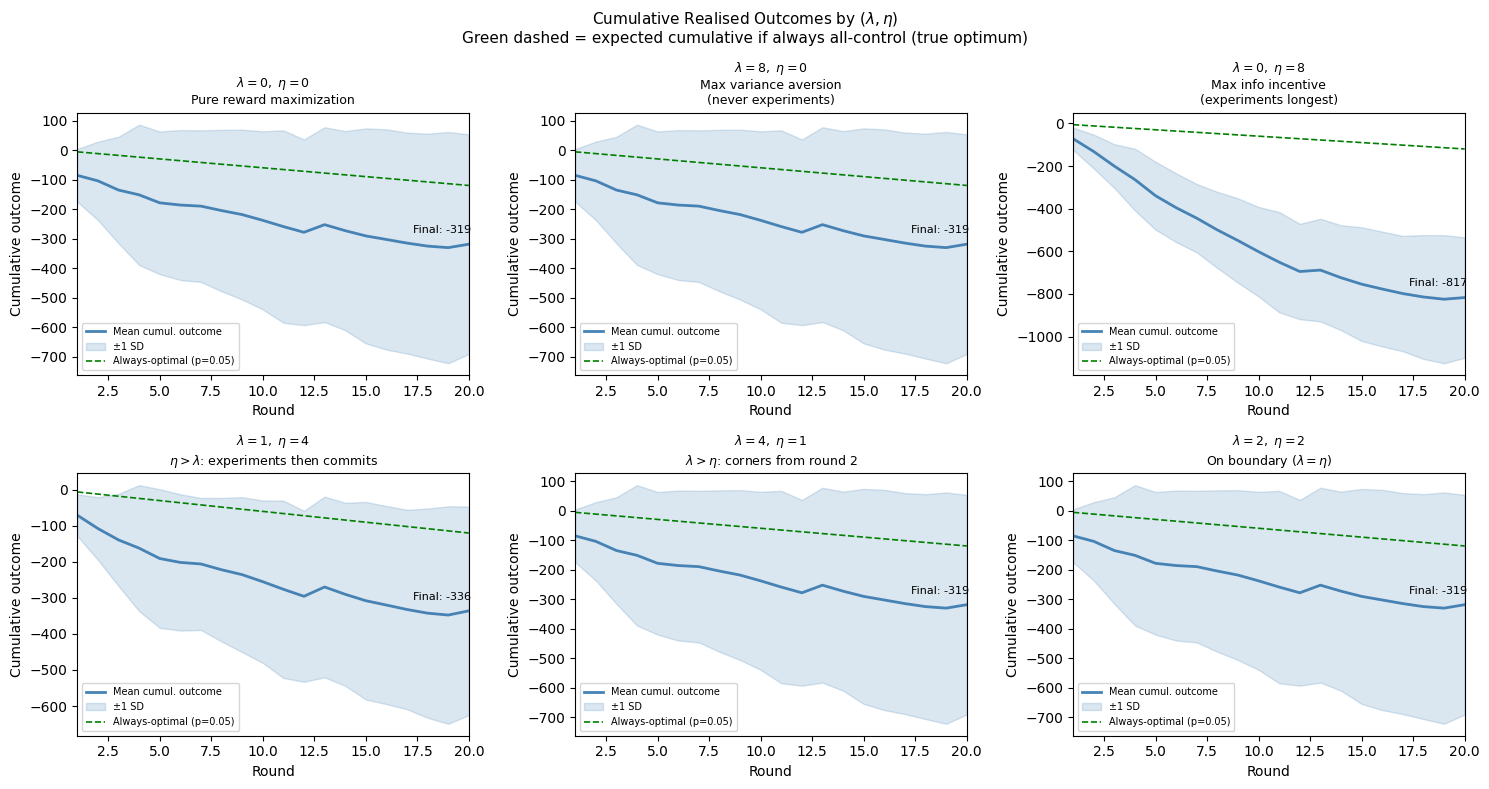

In [8]:
# --- Cumulative outcome trajectories for selected cases ---
# Benchmark: always allocate p=0.05 (optimal policy if treatment is known bad)
opt_p = p_grid[0]   # 0.05
opt_n_t = min(max(int(round(n_per_round * opt_p)), 1), n_per_round - 1)
opt_per_round = opt_n_t * true_effect   # expected per round (control mean = 0)
opt_cumulative = np.cumsum(np.full(T, opt_per_round))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
rounds = np.arange(1, T + 1)

for ax, (lam, eta, label) in zip(axes.flat, cases):
    dat = sweep_outcomes[(lam, eta)]['outcomes']      # (n_runs, T)
    cumdat = np.cumsum(dat, axis=1)                   # (n_runs, T)
    m = cumdat.mean(axis=0)
    s = cumdat.std(axis=0)
    ax.plot(rounds, m, linewidth=2, color='steelblue', label='Mean cumul. outcome')
    ax.fill_between(rounds, m - s, m + s, alpha=0.2, color='steelblue', label='±1 SD')
    ax.plot(rounds, opt_cumulative, linestyle='--', color='green',
            linewidth=1.2, label='Always-optimal (p=0.05)')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Round')
    ax.set_ylabel('Cumulative outcome')
    ax.set_xlim(1, T)
    ax.legend(fontsize=7)
    ax.annotate(f'Final: {m[-1]:.0f}', xy=(T, m[-1]),
                xytext=(-40, 8), textcoords='offset points', fontsize=8)

plt.suptitle('Cumulative Realised Outcomes by $(\\lambda, \\eta)$\n'
             'Green dashed = expected cumulative if always all-control (true optimum)',
             fontsize=11)
plt.tight_layout()
plt.show()

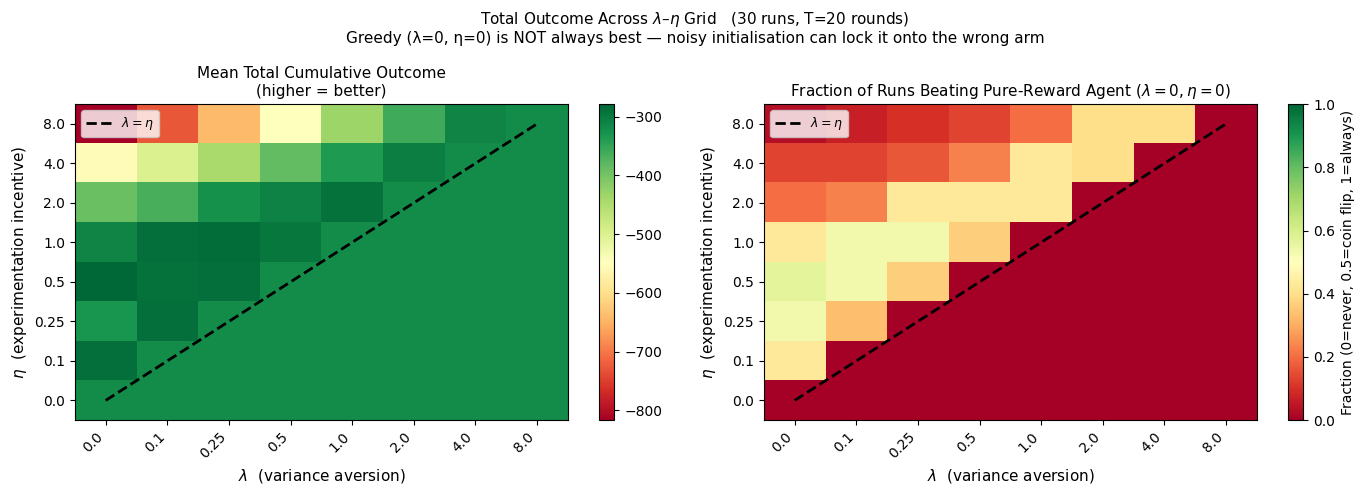


Mean total outcome, pure-reward (λ=0, η=0):  -319.1
Best mean total outcome in grid:              -278.8  at λ=0.0, η=0.5


In [9]:
# --- Heatmap: mean total cumulative outcome across lambda-eta grid ---
total_outcome = np.zeros((nE, nL))
frac_beats_greedy = np.zeros((nE, nL))   # fraction of runs that beat (0,0) agent

greedy_total = np.cumsum(sweep_outcomes[(0.0, 0.0)]['outcomes'], axis=1)[:, -1]  # (n_runs,)

for i, eta in enumerate(eta_vals):
    for j, lam in enumerate(lambda_vals):
        runs_cum = np.cumsum(sweep_outcomes[(lam, eta)]['outcomes'], axis=1)[:, -1]
        total_outcome[i, j]      = runs_cum.mean()
        frac_beats_greedy[i, j]  = (runs_cum > greedy_total).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: mean total outcome
im1 = axes[0].imshow(total_outcome, origin='lower', aspect='auto', cmap='RdYlGn')
axes[0].set_xticks(range(nL)); axes[0].set_xticklabels([str(v) for v in lambda_vals], rotation=45, ha='right')
axes[0].set_yticks(range(nE)); axes[0].set_yticklabels([str(v) for v in eta_vals])
axes[0].set_xlabel(r'$\lambda$  (variance aversion)', fontsize=11)
axes[0].set_ylabel(r'$\eta$  (experimentation incentive)', fontsize=11)
axes[0].set_title('Mean Total Cumulative Outcome\n(higher = better)', fontsize=11)
axes[0].plot(range(min(nL, nE)), range(min(nL, nE)), 'k--', linewidth=2, label=r'$\lambda=\eta$')
axes[0].legend(fontsize=9)
plt.colorbar(im1, ax=axes[0])

# Panel 2: fraction of runs beating the pure-reward agent (0,0)
im2 = axes[1].imshow(frac_beats_greedy, origin='lower', aspect='auto',
                     cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_xticks(range(nL)); axes[1].set_xticklabels([str(v) for v in lambda_vals], rotation=45, ha='right')
axes[1].set_yticks(range(nE)); axes[1].set_yticklabels([str(v) for v in eta_vals])
axes[1].set_xlabel(r'$\lambda$  (variance aversion)', fontsize=11)
axes[1].set_ylabel(r'$\eta$  (experimentation incentive)', fontsize=11)
axes[1].set_title(r'Fraction of Runs Beating Pure-Reward Agent ($\lambda=0,\eta=0$)', fontsize=11)
axes[1].plot(range(min(nL, nE)), range(min(nL, nE)), 'k--', linewidth=2, label=r'$\lambda=\eta$')
axes[1].legend(fontsize=9)
plt.colorbar(im2, ax=axes[1], label='Fraction (0=never, 0.5=coin flip, 1=always)')

plt.suptitle('Total Outcome Across $\\lambda$–$\\eta$ Grid   (30 runs, T=20 rounds)\n'
             'Greedy (λ=0, η=0) is NOT always best — noisy initialisation can lock it onto the wrong arm',
             fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nMean total outcome, pure-reward (λ=0, η=0):  {total_outcome[0,0]:.1f}")
print(f"Best mean total outcome in grid:              {total_outcome.max():.1f}  "
      f"at λ={lambda_vals[np.unravel_index(total_outcome.argmax(), total_outcome.shape)[1]]}, "
      f"η={eta_vals[np.unravel_index(total_outcome.argmax(), total_outcome.shape)[0]]}")

## Interpretation

### What the heatmap shows
- **Red (bottom-right, high $\lambda$, low $\eta$):** Agent commits to the all-control corner by round 2 and never deviates. The variance penalty dominates the information bonus from the first round with data.
- **Green (top-left, low $\lambda$, high $\eta$):** Agent holds near balanced allocation for many rounds. Estimation noise is large enough early that the information bonus outweighs the variance cost of balance.
- **Late heatmap is much redder:** Once ~5+ rounds of data accumulate, estimation noise shrinks and the information bonus collapses for every agent. All agents converge to the all-control corner eventually — $\lambda$/$\eta$ governs *speed*, not *direction*.

### The $\lambda = \eta$ boundary
The dashed diagonal roughly separates the red and green regions in the early heatmap, matching the theoretical prediction. Interior allocation requires both $\eta > \lambda$ **and** large estimation noise (early rounds).

### Key result
The v2 loss produces the desired dynamics with a single free parameter ratio $\lambda/\eta$:
1. **Early:** High uncertainty → large estimation noise → information bonus active → $\eta > \lambda$ agents experiment
2. **Late:** Low uncertainty → estimation noise $\approx 0$ → information bonus gone → all agents commit to control
3. **High-$\lambda$ agents** never experiment regardless of $\eta$ (if $\lambda > \eta$)
4. The $\lambda/\eta$ ratio is the key sufficient statistic: $\lambda/\eta < 1$ experiments; $\lambda/\eta \geq 1$ never does